# UVIETOBORE JOSHUA ADJUGAH
# REG. NO.: 33911786

# 1. Title Page

## A Comparative Study of Machine Learning Models for Early Stroke Risk Prediction
- Machine Learning Mini-Project
- Student: 33911786
- FT MSC DATA SCIENCE AND ARTIFICIAL INTELLIGENCE

# 2. Table of Contents

- Introduction & Problem Formulation
- Dataset Description
- Exploratory Data Analysis
- Data Preprocessing
- Model Training and Evaluation
- Results & Discussion
- Comparison with Rahman and Hasan (2020)
- Conclusion
- References

# 3. Introduction & Problem Formulation

Stroke is widely recognised as one of the leading causes of death and long-term disability worldwide, representing a major public health challenge with profound social, economic, and healthcare implications. Individuals who survive a stroke often experience permanent physical, cognitive, or psychological impairments, leading to reduced quality of life and long-term dependence on healthcare and social support services. From a healthcare system perspective, stroke-related treatment, rehabilitation, and long-term care place significant strain on limited medical resources. As a result, strategies that focus on prevention and early risk identification are increasingly prioritised within public health policy and clinical practice.

Early identification of individuals at elevated risk of stroke is particularly critical, as many stroke-related risk factors are modifiable through lifestyle changes, medical intervention, or continuous monitoring. Conditions such as hypertension, abnormal glucose levels, obesity, and cardiovascular disease are well-established contributors to stroke risk, and timely intervention in high-risk individuals has been shown to substantially reduce both morbidity and mortality. Consequently, the ability to accurately identify individuals who are more likely to experience a stroke before its occurrence has considerable clinical value, supporting proactive rather than reactive healthcare delivery.

In recent years, advances in machine learning and data-driven modelling have created new opportunities for enhancing clinical decision support systems. Machine learning algorithms are capable of analysing large volumes of healthcare data and identifying complex, non-linear relationships between risk factors that may not be easily captured using traditional statistical methods. These capabilities make machine learning particularly suitable for medical risk prediction tasks, including stroke prediction, where multiple interacting variables influence patient outcomes. However, despite their potential, the application of machine learning in healthcare introduces a number of methodological and practical challenges that must be carefully addressed.

One of the primary challenges in stroke prediction is the issue of class imbalance. In most healthcare datasets, the number of individuals who experience a stroke is significantly smaller than the number of individuals who do not. This imbalance can bias machine learning models towards predicting the majority class, leading to high overall accuracy but poor performance in identifying actual stroke cases. In a clinical context, such behaviour is unacceptable, as false negative, failing to identify individuals at risk can have severe and potentially life-threatening consequences. Therefore, model development must go beyond accuracy-based evaluation and instead focus on metrics that better reflect clinical priorities.

Another important challenge is the selection of appropriate evaluation metrics. While accuracy and ROC–AUC are commonly reported in machine learning studies, they do not fully capture the cost-sensitive nature of medical prediction tasks. In stroke prediction, recall is of particular importance, as it measures the model’s ability to correctly identify individuals who will experience a stroke. A model with high recall ensures that fewer high-risk individuals are missed, even if this comes at the expense of lower precision. Balancing these trade-offs requires careful metric selection, threshold adjustment, and critical interpretation of model performance in relation to real-world clinical objectives.

The objective of this project is to develop, evaluate, and critically compare multiple supervised machine learning classification models for predicting the likelihood of stroke using demographic and clinical features derived from a structured healthcare dataset. The modelling pipeline includes comprehensive data preprocessing, feature engineering, and imbalance training strategies. Several models are implemented and evaluated, including a baseline Logistic Regression model, an ensemble-based method, and a Neural Network, allowing for a systematic comparison between interpretable linear models and more complex non-linear approaches.

Model performance is assessed using a range of evaluation metrics suitable for imbalanced datasets, including precision, recall, F1-score, and ROC–AUC. Particular emphasis is placed on recall, reflecting the clinical objective of minimising missed stroke cases. Decision threshold tuning is incorporated to further align model predictions with healthcare priorities, demonstrating how predictive performance can be adjusted to suit domain-specific requirements rather than relying on default classification thresholds.

Beyond predictive performance, this project critically examines the strengths and limitations of each modelling approach, with particular focus on interpretability, generalisation, and real-world applicability within a healthcare setting. By evaluating both simple and complex models using a consistent framework, the project emphasises the importance of appropriate evaluation metrics, and domain-informed decision-making in medical machine learning.

Overall, this project demonstrates how machine learning techniques, when carefully designed and evaluated, can support early stroke risk identification and contribute to data-informed clinical decision support. The findings reinforce the notion that effective healthcare modelling is not solely dependent on model complexity, but rather on the alignment between data characteristics, modelling choices, and real-world clinical objectives.

# 4. Dataset Description

The dataset used in this project is the Stroke Prediction Dataset, obtained from the Kaggle repository. The dataset contains anonymised demographic and clinical information for individuals, with the objective of predicting whether a stroke event occurred.
The dataset consists of approximately 5,000 observations, where each observation represents an individual, and 11 input features describing demographic characteristics, lifestyle factors, and medical conditions. The target variable is a binary indicator labelled stroke, where a value of 1 denotes that the individual experienced a stroke, and 0 denotes no stroke event.

### Features

The input features included in the dataset are:

- gender: Gender of the individual
- age: Age in years
- hypertension: Binary indicator of hypertension
- heart_disease: Binary indicator of heart disease
- ever_married: Marital status
- work_type: Type of employment
- Residence_type: Urban or rural residence
- avg_glucose_level: Average glucose level in blood
- bmi: Body Mass Index
- smoking_status: Smoking history

### Target Variable

- stroke: Binary outcome indicating whether an individual experienced a stroke (1) or not (0)


### Dataset Characteristics

The dataset exhibits class imbalance, with stroke cases representing a small proportion of the total observations. This characteristic reflects real-world clinical data but presents a challenge for standard classification models, as high accuracy may be achieved by simply predicting the majority class. Evaluation metrics such as recall, precision, and F1-score are more appropriate for assessing model performance than accuracy alone.

Additionally, the dataset contains missing values in the bmi feature, which are addressed during the data preprocessing stage. Several categorical variables are also present and require appropriate encoding prior to model training.

Overall, the dataset provides a realistic and suitable foundation for evaluating machine learning models for early stroke risk prediction while remaining computationally manageable for experimentation on standard hardware.

---

All the libraries required for data manipulation, visualisation, model building, and evaluation are imported. NumPy and pandas are used for numerical operations and structured data handling, even for the data preprocessing workflow. Seaborn and Matplotlib are included for exploratory data analysis and visualisation, enabling patterns, distributions, and relationships within the data to be examined. Scikit-learn utilities are imported for dataset splitting, feature scaling, and evaluation metrics, ensuring a standardised and reproducible machine learning pipeline. TensorFlow Keras modules are imported to construct and train the neural network model, while the EarlyStopping callback is included to prevent overfitting by monitoring validation performance during training. All these imports establish the full analytical environment required for developing, training, and evaluating the classification model.

In [643]:
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, Dropout
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

This cell loads the stroke prediction dataset from a CSV file into a pandas DataFrame and displays the first ten rows to confirm that the data has been imported correctly. The transpose is used to make the features easier to read.

In [644]:
df = pd.read_csv('StrokePredictionDataset.csv')
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
id,9046,51676,31112,60182,1665,56669,53882,10434,27419,60491
gender,Male,Female,Male,Female,Female,Male,Male,Female,Female,Female
age,67.0,61.0,80.0,49.0,79.0,81.0,74.0,69.0,59.0,78.0
hypertension,0,0,0,0,1,0,1,0,0,0
heart_disease,1,0,1,0,0,0,1,0,0,0
ever_married,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes
work_type,Private,Self-employed,Private,Private,Self-employed,Private,Private,Private,Private,Private
Residence_type,Urban,Rural,Rural,Urban,Rural,Urban,Rural,Urban,Rural,Urban
avg_glucose_level,228.69,202.21,105.92,171.23,174.12,186.21,70.09,94.39,76.15,58.57
bmi,36.6,NaN,32.5,34.4,24.0,29.0,27.4,22.8,NaN,24.2


This cell provides a summary of the dataset, including the number of entries, feature data types, and the presence of missing values. It helps identify which variables are numerical or categorical and highlights any columns that may require preprocessing or cleaning.

In [645]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


This cell displays the shape of the dataset, showing the number of rows and columns. This helps confirm the dataset size and ensures the data matches expectations before further analysis.

In [646]:
df.shape

(5110, 12)

### Summary statistics of numerical features

This cell generates descriptive statistics for the numerical variables, including measures such as mean, standard deviation, minimum, and maximum values. It helps identify the scale, distribution, and potential outliers in the data.

In [647]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Check for missing and duplicate values

This cell checks data quality by counting missing values in each column and identifying any duplicated rows in the dataset. This helps determine whether data cleaning steps such as imputation or duplicate removal are required before further analysis.

In [648]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [649]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [650]:
df.duplicated().sum()

0

### Remove non-informative identifier column

This cell removes the id column from the dataset, as it is only an identifier and does not contain predictive information. Keeping such columns could introduce noise without improving model performance.

In [651]:
df.drop(columns='id', inplace=True)

In this cell, the hypertension and heart_disease columns are converted from binary numerical values to categorical labels. This transformation makes it easier to generate meaningful summary statistics and explore the relationship between hypertension, heart disease, and stroke across the dataset before turning it back to binary numerical values for modelling.

In [652]:
df['hypertension'].replace({0:'No', 1:'Yes'}, inplace=True)
df['heart_disease'].replace({0:'No', 1:'Yes'}, inplace=True)

/var/folders/n6/c4lth3xd22b420jmnbprqgbh0000gn/T/ipykernel_36046/323722347.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['hypertension'].replace({0:'No', 1:'Yes'}, inplace=True)
/var/folders/n6/c4lth3xd22b420jmnbprqgbh0000gn/T/ipykernel_36046/323722347.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

---

This cell displays the first few rows of the dataset to confirm that the hypertension and heart_disease columns have been correctly converted to categorical labels.

In [653]:
df.head().T

,0,1,2,3,4
gender,Male,Female,Male,Female,Female
age,67.0,61.0,80.0,49.0,79.0
hypertension,No,No,No,No,Yes
heart_disease,Yes,No,Yes,No,No
ever_married,Yes,Yes,Yes,Yes,Yes
work_type,Private,Self-employed,Private,Private,Self-employed
Residence_type,Urban,Rural,Rural,Urban,Rural
avg_glucose_level,228.69,202.21,105.92,171.23,174.12
bmi,36.6,NaN,32.5,34.4,24.0
smoking_status,formerly smoked,never smoked,never smoked,smokes,never smoked


### Identifying categorical and numerical features

In this cell, the dataset features are classified into categorical and numerical variables based on their data types. Categorical features typically represent qualitative information and require encoding before being used in machine learning models, while numerical features can be directly scaled and used for model training. Separating features in this way helps guide appropriate preprocessing steps, such as encoding categorical variables and applying scaling techniques to numerical variables, ensuring the data is prepared correctly for subsequent analysis and modelling.

In [654]:
cat_col = []
num_col = []

for col in df.columns:
    if df[col].dtype == 'object':
        cat_col.append(col)
    else:
        num_col.append(col)

print(f'The Categorical columns are: {cat_col}')
print(f'The Numerical columns are: {num_col}')

The Categorical columns are: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
The Numerical columns are: ['age', 'avg_glucose_level', 'bmi', 'stroke']


# 5. Exploratory Data Analysis

In this section, exploratory data analysis is conducted to better understand the dataset, identify patterns and relationships between variables, and detect potential issues such as class imbalance or outliers. The insights gained here help inform feature selection, preprocessing decisions, and model development.

### Examine class distribution of the target variable

This cell displays the distribution of the target variable (stroke) to assess class balance within the dataset. Understanding the proportion of stroke and non-stroke cases is important, as class imbalance can significantly influence model training and evaluation.

In [655]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

### Distribution of categorical variables

This cell visualises the frequency distribution of each categorical feature in the dataset. Bar charts are used to show how observations are distributed across categories, helping to identify dominant groups, class imbalance, and potential irregularities within categorical variables.

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


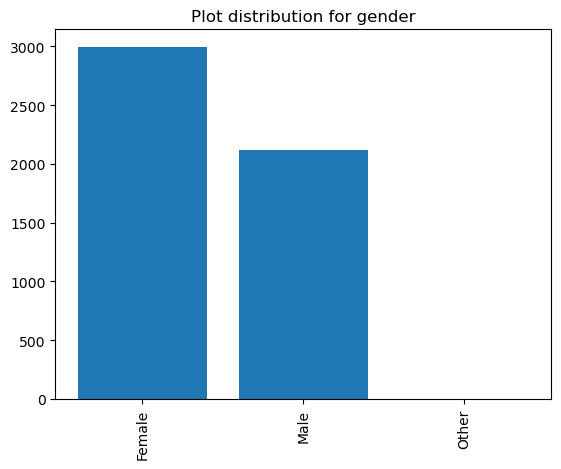

hypertension
No     4612
Yes     498
Name: count, dtype: int64


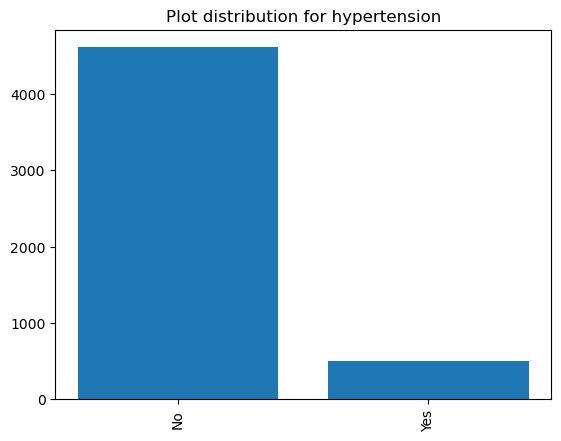

heart_disease
No     4834
Yes     276
Name: count, dtype: int64


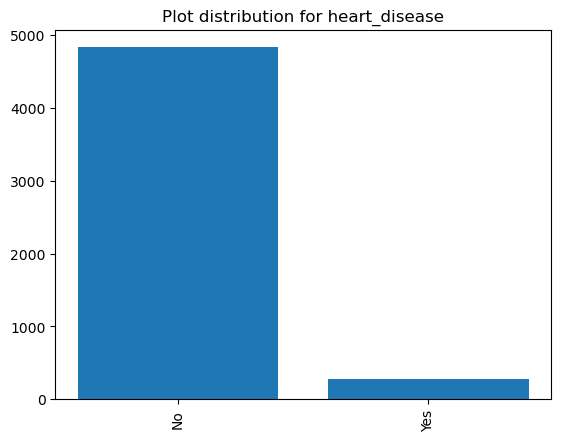

ever_married
Yes    3353
No     1757
Name: count, dtype: int64


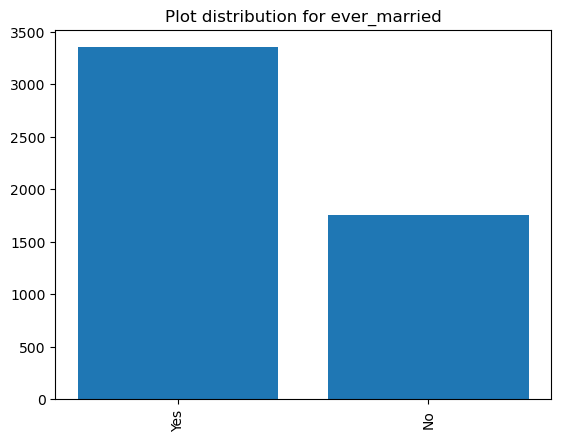

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


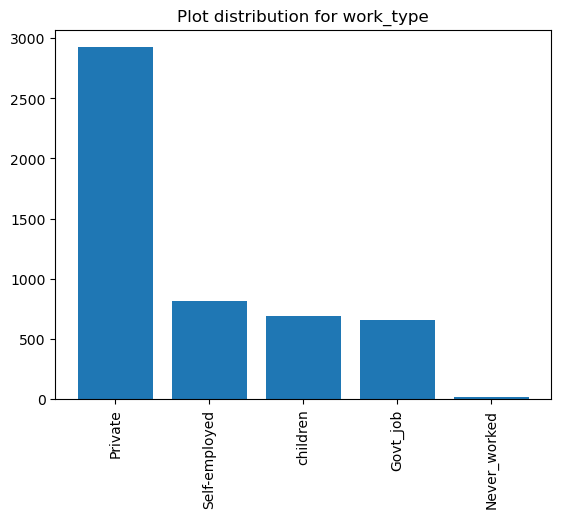

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


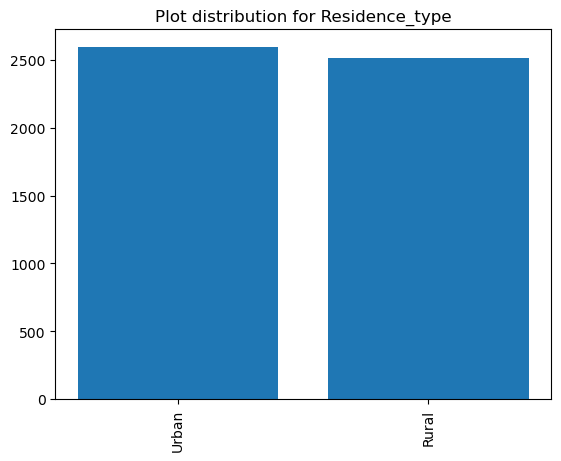

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


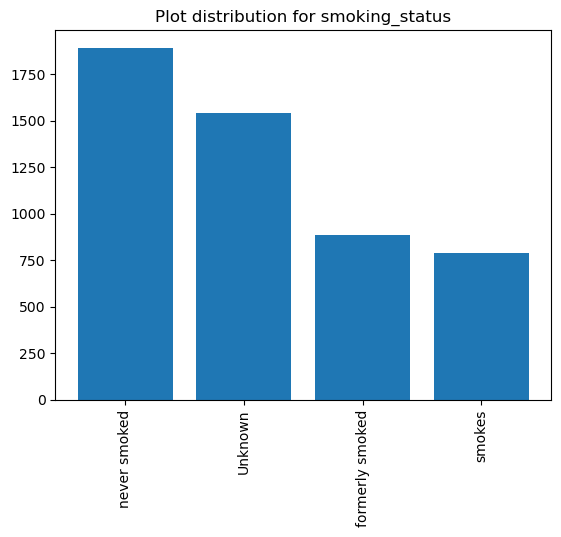

In [656]:
for column in cat_col:
    vcount = df[column].value_counts()
    print(vcount)
    plt.bar(vcount.index, vcount.values)
    plt.title(f"Plot distribution for {column}")
    plt.xticks(rotation=90)
    plt.show()

This cell isolates observations where the smoking status is recorded as “Unknown” in order to better understand this group. The “Unknown” category may include individuals who are reluctant to disclose their smoking behaviour, possibly due to privacy concerns or uncertainty about data anonymity. As a result, this group may contain a proportion of smokers who chose not to report their status. Examining these records separately helps ensure that this category is interpreted cautiously during analysis and modelling.

In [657]:
df[df['smoking_status'] == "Unknown"]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
8,Female,59.0,No,No,Yes,Private,Rural,76.15,NaN,Unknown,1
9,Female,78.0,No,No,Yes,Private,Urban,58.57,24.2,Unknown,1
13,Male,78.0,No,Yes,Yes,Private,Urban,219.84,NaN,Unknown,1
19,Male,57.0,No,Yes,No,Govt_job,Urban,217.08,NaN,Unknown,1
23,Male,82.0,No,Yes,Yes,Private,Rural,208.30,32.5,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...
5098,Male,9.0,No,No,No,children,Urban,71.88,17.5,Unknown,0
5101,Female,45.0,No,No,Yes,Private,Urban,97.95,24.5,Unknown,0
5103,Female,18.0,No,No,No,Private,Urban,82.85,46.9,Unknown,0
5104,Female,13.0,No,No,No,children,Rural,103.08,18.6,Unknown,0


### Distribution of numerical variables

This cell visualises the distribution of each numerical feature using histograms. Plotting these distributions helps assess the range, spread, and shape of the data, and allows potential skewness or outliers to be identified before applying scaling or modelling techniques.

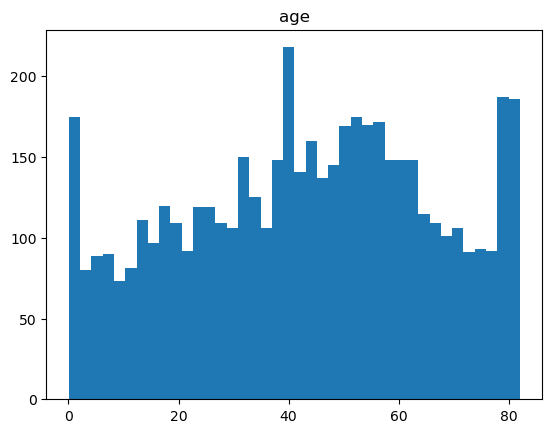

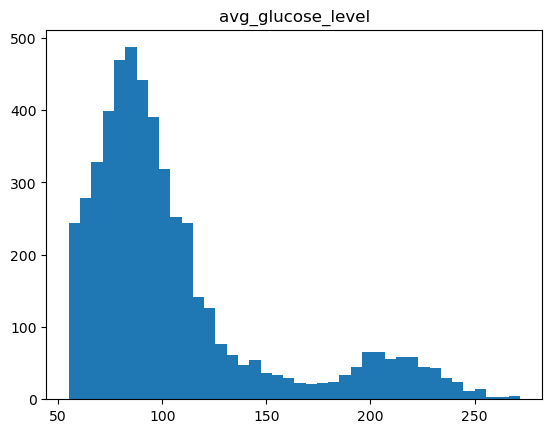

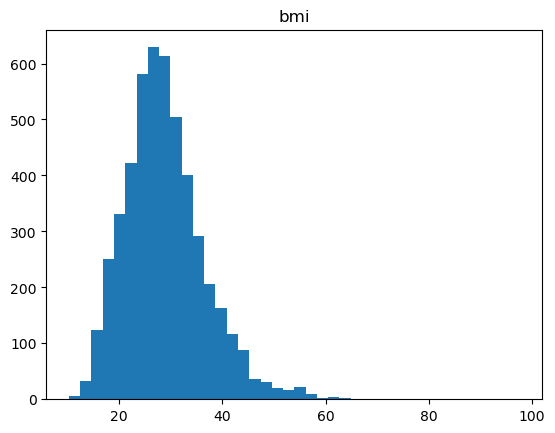

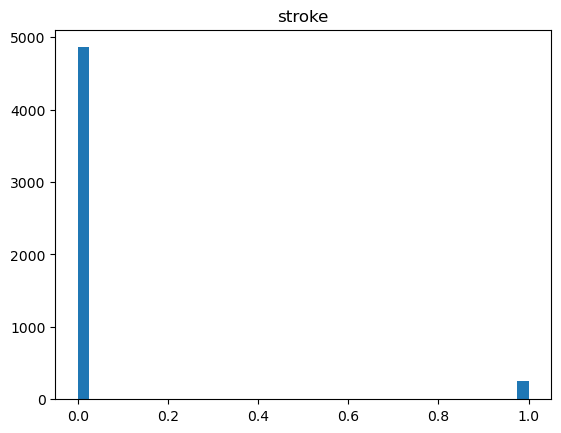

In [658]:
for col in num_col:
    plt.figure()
    plt.hist(df[col].dropna(), bins=40)
    plt.title(col)
    plt.show()

### Grouped analysis of numerical features by categorical variables

This cell performs a grouped analysis, calculating the mean values of numerical features for each category within the categorical variables. This allows us to explore relationships and patterns between categorical factors (like hypertension or smoking_status) and numerical measurements (such as age, avg_glucose_level, or bmi). Such analysis can highlight potential risk factors and trends that may be relevant for predicting the target variable (stroke).

In [659]:
for col in cat_col:
    print(f"\nGrouped Analysis by: {col}")
    print(df.groupby(col)[num_col].mean().round(2))
    print("\n")


Grouped Analysis by: gender
          age  avg_glucose_level    bmi  stroke
gender                                         
Female  43.76             104.06  29.07    0.05
Male    42.48             109.09  28.65    0.05
Other   26.00             143.33  22.40    0.00



Grouped Analysis by: hypertension
                age  avg_glucose_level    bmi  stroke
hypertension                                         
No            41.17             103.55  28.47    0.04
Yes           62.24             130.19  33.04    0.13



Grouped Analysis by: heart_disease
                 age  avg_glucose_level    bmi  stroke
heart_disease                                         
No             41.80             104.40  28.82    0.04
Yes            68.19             136.82  30.32    0.17



Grouped Analysis by: ever_married
                age  avg_glucose_level    bmi  stroke
ever_married                                         
No            22.01              96.45  25.21    0.02
Yes           54.34  

### What the grouped analysis says

- Females have a slightly higher BMI, while males have slightly higher average glucose levels, but stroke prevalence is similar between genders, suggesting gender may have limited predictive power.

- Higher age, BMI, and glucose levels are associated with hypertension, and hypertensive individuals have a much higher stroke rate (13% vs 4%), indicating hypertension is a strong stroke risk factor.

- Similarly, higher age, BMI, and glucose levels are associated with heart disease, and those with heart disease have an elevated stroke risk (17% vs 4%), confirming its importance for prediction.

- People who have been married tend to have higher age, BMI, and glucose levels, and show higher stroke prevalence (7% vs 2%), suggesting marital status may partially reflect accumulated health risk.

- Residence type shows little difference in stroke rates, indicating urban/rural location may have limited influence.

- For smoking status, former smokers have the highest age, BMI, and glucose levels, and the highest stroke rate (8%), reflecting accumulated health risks. Current smokers and never-smokers show similar stroke prevalence (~5%), while the “Unknown” group is younger with lower risk, suggesting careful interpretation is required.

Overall, age, BMI, glucose level, hypertension, and heart disease emerge as the most relevant risk factors, which will inform feature selection, scaling, and class imbalance handling during model training.

---

The scatter plot shows that most individuals are clustered at younger ages with normal or moderately elevated glucose levels, forming the dense “sea” at the base. This suggests that the majority of the population in the dataset is relatively healthy, with glucose levels within a common range. A smaller number of points are spread out toward older ages and higher glucose levels, representing individuals with potential health risks such as diabetes or pre-diabetes. The upward trend in these sparse points indicates that average glucose levels tend to increase with age, which aligns with known medical patterns where older adults are more likely to have elevated glucose. The high density of points at the lower end also explains why the base appears very thick, highlighting that most of the population falls in a lower-risk category. Overall, while there is no single strict correlation, the plot suggests that age is a contributing factor to higher glucose levels, which may in turn increase stroke risk for older individuals.

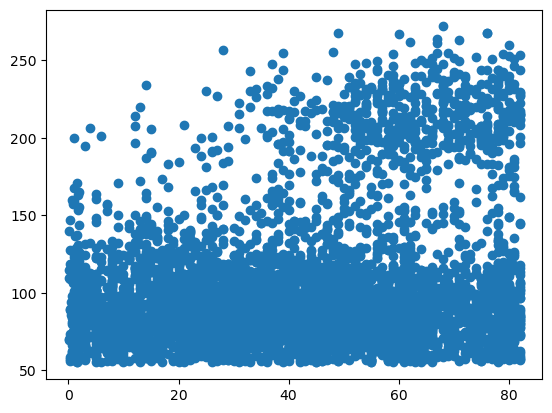

In [660]:
plt.scatter(df['age'], df['avg_glucose_level'])
plt.show()

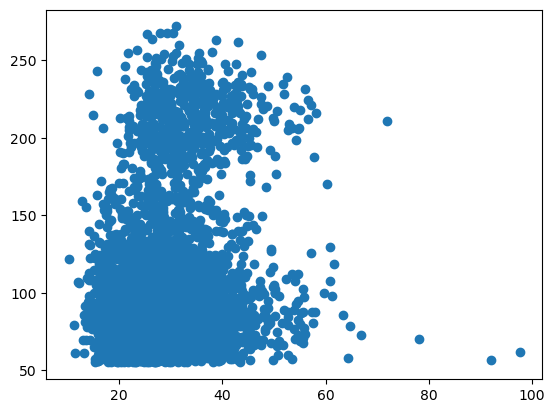

In [661]:
plt.scatter(df['bmi'], df['avg_glucose_level'])
plt.show()

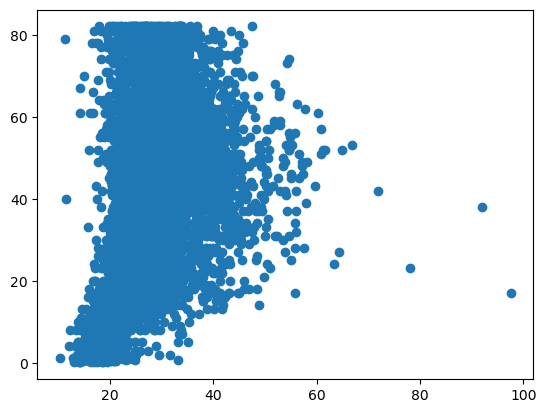

In [662]:
plt.scatter(df['bmi'], df['age'])
plt.show()

### Encode categorical variables into numeric values

All categorical variables are converted into numerical codes so they can be used as inputs for the machine learning model. Binary categories such as gender, ever_married, hypertension, and heart_disease are encoded as 0/1. Multi-class variables like work_type and smoking_status are assigned integer codes to preserve distinct categories, while Residence_type is encoded as 0/1. This step is essential because neural networks require numerical inputs and cannot directly process text labels. Encoding ensures that the data is in a consistent, machine-readable format for model training.

In [663]:
df['gender'] = df['gender'].replace({'Male':0, 'Female':1})
df['ever_married'] = df['ever_married'].replace({'No':0, 'Yes':1})
df['work_type'] = df['work_type'].replace({'children':0, 'Never_worked':1, 'Self-employed':2, 'Govt_job':3, 'Private':4})
df['Residence_type'] = df['Residence_type'].replace({'Rural':0, 'Urban':1})
df['smoking_status'] = df['smoking_status'].replace({'never smoked':-1, 'Unknown':0, 'formerly smoked':1, 'smokes':2})
df['hypertension'] = df['hypertension'].replace({'No':0, 'Yes':1})
df['heart_disease'] = df['heart_disease'].replace({'No':0, 'Yes':1})

/var/folders/n6/c4lth3xd22b420jmnbprqgbh0000gn/T/ipykernel_36046/3308030418.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ever_married'] = df['ever_married'].replace({'No':0, 'Yes':1})
/var/folders/n6/c4lth3xd22b420jmnbprqgbh0000gn/T/ipykernel_36046/3308030418.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['work_type'] = df['work_type'].replace({'children':0, 'Never_worked':1, 'Self-employed':2, 'Govt_job':3, 'Private':4})
/var/folders/n6/c4lth3xd22b420jmnbprqgbh0000gn/T/ipykernel_36046/3308030418.py:4: FutureWar

### Remove outlier for gender

This cell removes the single record where gender is recorded as “Other.” Since this is the only instance and neural networks require consistent input encoding, keeping it could introduce noise. Removing this row ensures the dataset only contains Male and Female categories, which simplifies preprocessing and model training.

In [664]:
df[df['gender'] == 'Other']

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,Other,26.0,0,0,0,4,0,143.33,22.4,1,0


In [665]:
df.drop(index=3116, inplace=True)

### Visualise feature distributions and detect outliers

This cell generates boxplots for all features in the dataset. Boxplots provide a clear view of the median, quartiles, and potential outliers for each variable, helping identify extreme values that may need handling before scaling or model training. They are particularly useful for spotting skewed distributions in numerical features.

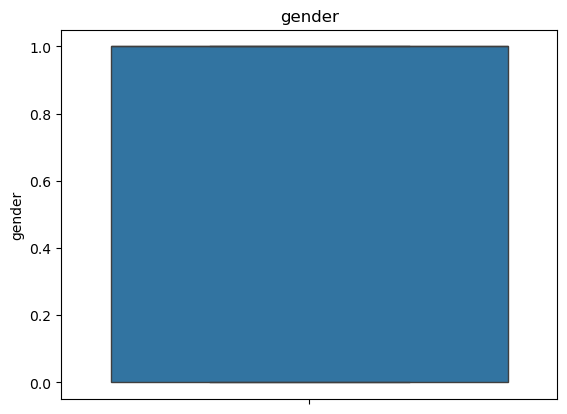

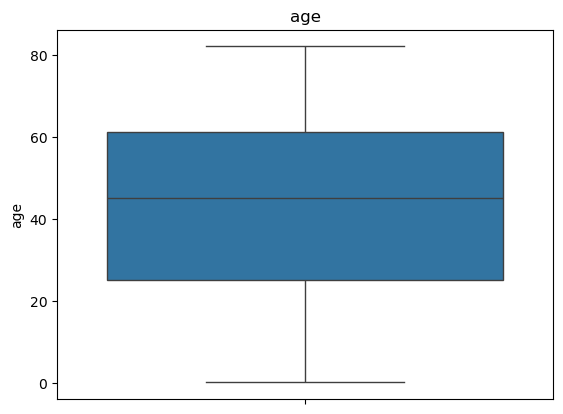

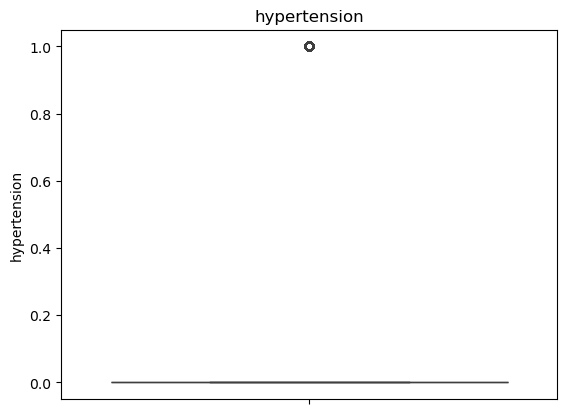

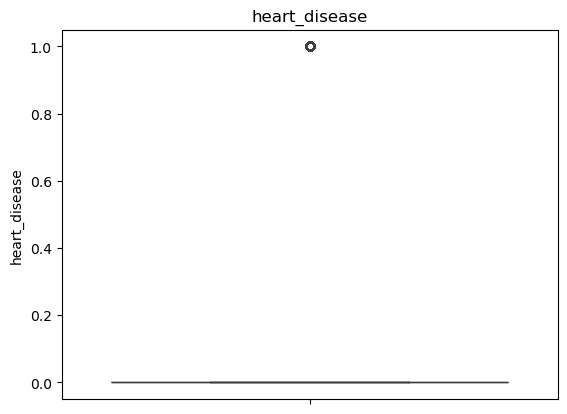

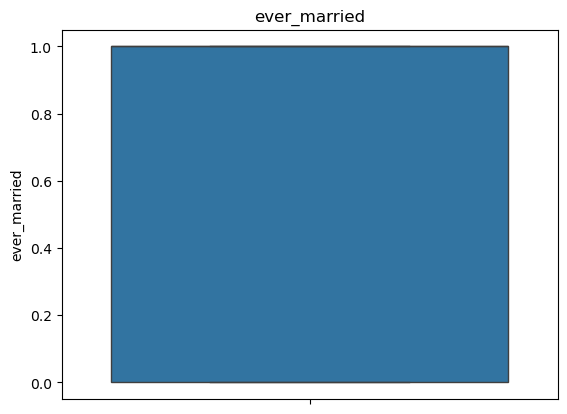

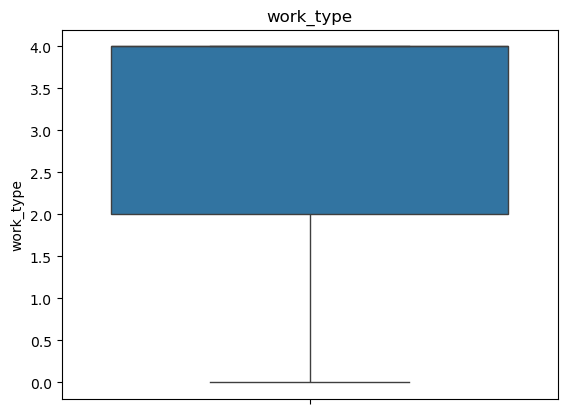

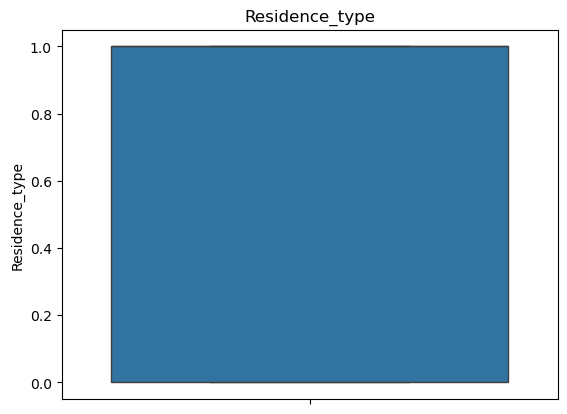

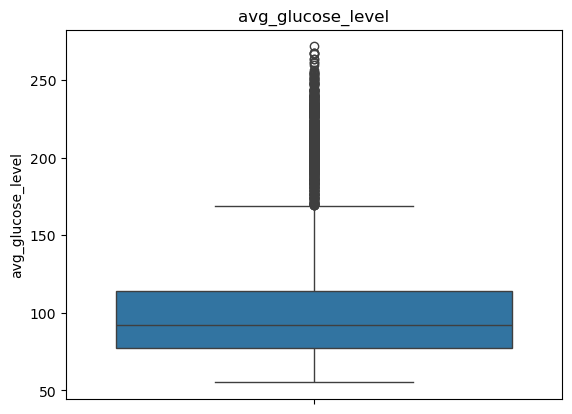

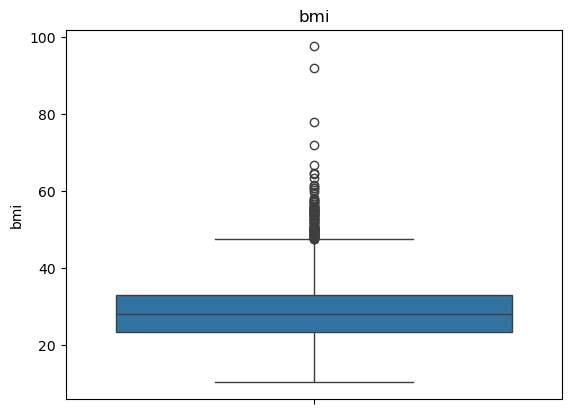

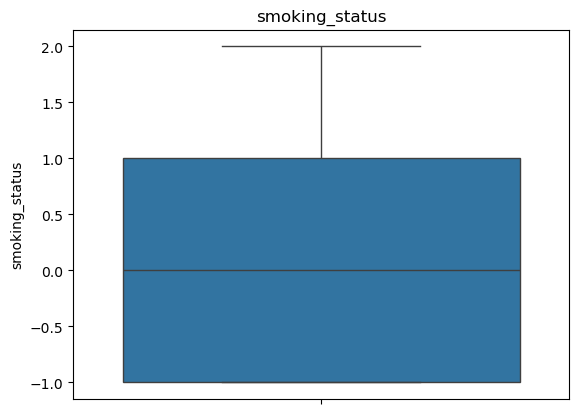

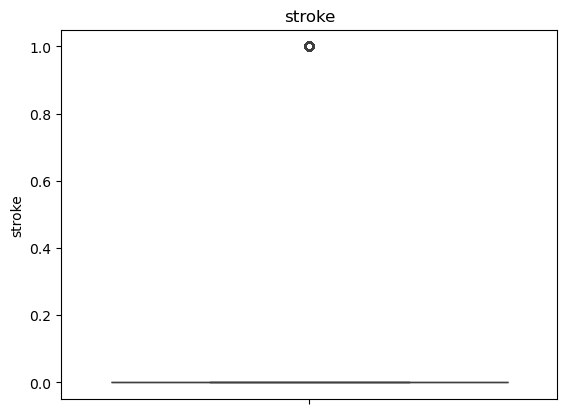

In [666]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.title(i)
    plt.show()

Outlier focus based on boxplots

From the boxplots, outliers are most noticeable in the avg_glucose_level and bmi columns, which are continuous variables. Columns with only a few unique values (binary or categorical features) can produce misleading outlier signals because small category counts may appear extreme, and removing them could result in unnecessary loss of data. Therefore, we will focus on detecting and handling outliers only in the continuous features (avg_glucose_level and bmi) to preserve the dataset size while addressing the most meaningful extreme values.

# 6. Data Preprocessing

In this section, the dataset will be prepared for machine learning by addressing issues such as missing values, outliers, categorical encoding, and feature scaling. Proper preprocessing ensures that the data is clean, consistent, and suitable for training a neural network, which improves model performance and reliability.

### Identify missing values in BMI

This cell isolates rows where the bmi column has missing values. Since BMI is a key continuous feature and will be used in model training, it is important to identify and handle these missing entries before scaling or feeding the data into the neural network.

In [667]:
df[df['bmi'].isna()]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,1,61.0,0,0,1,2,0,202.21,NaN,-1,1
8,1,59.0,0,0,1,4,0,76.15,NaN,0,1
13,0,78.0,0,1,1,4,1,219.84,NaN,0,1
19,0,57.0,0,1,0,3,1,217.08,NaN,0,1
27,0,58.0,0,0,1,4,0,189.84,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...
5039,0,41.0,0,0,0,4,0,70.15,NaN,1,0
5048,0,40.0,0,0,1,4,1,191.15,NaN,2,0
5093,1,45.0,1,0,1,3,0,95.02,NaN,2,0
5099,0,40.0,0,0,1,4,0,83.94,NaN,2,0


### Impute missing BMI values

This cell fills the missing values in the bmi column with the mean BMI of the dataset. Using the mean preserves the overall distribution of the feature while allowing the dataset to remain complete for model training. Imputation ensures that no rows are dropped due to missing values, which helps maintain dataset size and model reliability.

In [668]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

This cell checks whether any missing values remain in the bmi column after imputation. It ensures that the previous step successfully filled all missing entries, confirming that the dataset is now complete for this feature.

In [669]:
df[df['bmi'].isna()]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


### Outlier focus based on boxplots

From the boxplots, outliers are most noticeable in the avg_glucose_level and bmi columns, which are continuous variables. Columns with only a few unique values (binary or categorical features) can produce misleading outlier signals because small category counts may appear extreme, and removing them could result in unnecessary loss of data. Therefore, we will focus on detecting and handling outliers only in the continuous features (avg_glucose_level and bmi) to preserve the dataset size while addressing the most meaningful extreme values.

#### Prepare columns for outlier detection

Based on the previous boxplot analysis, outliers are expected only in the continuous columns avg_glucose_level and bmi. This cell defines these columns in a list so that subsequent outlier detection and handling steps focus only on meaningful continuous features, preserving the rest of the dataset.

In [670]:
outlier_list = []

out_cols = ['avg_glucose_level', 'bmi']

### Detect outliers using the z-score method

This cell identifies outliers in the avg_glucose_level and bmi columns using the z-score method. Values with a z-score greater than 3 (more than 3 standard deviations from the mean) are considered outliers. The indices of these outliers are stored in outlier_list for further handling. This approach focuses only on continuous features, avoiding inappropriate removal of categorical or low-unique-value columns.

In [671]:
for column in out_cols:
    nm = (df[column] - np.mean(df[column])) / np.std(df[column])
    outlier_index = df[np.abs(nm) > 3].index
    outlier_list.extend(outlier_index)

### Remove detected outliers

This cell first identifies the unique outlier indices in the continuous columns (avg_glucose_level and bmi) and then removes these rows from the dataset. Dropping extreme values ensures that the model is not unduly influenced by rare, extreme measurements, while maintaining the overall integrity of the dataset.

In [672]:
unique_outliers = list(set(outlier_list))
len(unique_outliers)

108

In [673]:
df.loc[unique_outliers]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3588,0,43.0,0,0,1,4,1,100.16,59.7,-1,0
2567,1,48.0,0,0,1,4,1,57.43,53.5,1,0
3088,1,76.0,0,0,1,2,1,267.61,27.9,2,0
3606,0,45.0,1,0,1,2,0,239.19,52.5,0,0
1559,1,53.0,0,0,1,4,0,72.63,66.8,0,0
...,...,...,...,...,...,...,...,...,...,...,...
3060,0,49.0,0,0,1,2,0,215.81,58.1,-1,0
4598,1,56.0,0,0,1,3,0,244.30,37.3,-1,0
1529,1,82.0,0,0,1,4,1,253.16,47.5,0,0
2555,1,56.0,0,0,1,3,1,102.51,55.7,0,0


In [674]:
df.drop(unique_outliers, inplace=True)

### Verify dataset size after outlier removal

This cell displays the shape of the dataset after removing outliers. It ensures that the dataset still contains a sufficient number of observations for model training and that the previous outlier removal step was applied correctly.

In [675]:
df.shape

(5001, 11)

### Examine feature correlations

This cell computes the correlation matrix for all numerical features in the dataset. Correlation analysis helps identify relationships between variables, detect multicollinearity, and understand which features may be strongly associated with the target (stroke). This insight can guide feature selection and model interpretation.

In [676]:
df.corr()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
gender,1.000000,0.028870,-0.017136,-0.084230,0.030907,0.070321,0.004243,-0.054480,0.019465,-0.068821,-0.003400
age,0.028870,1.000000,0.277499,0.262937,0.681152,0.432114,0.014486,0.219090,0.359504,0.078177,0.243808
hypertension,-0.017136,0.277499,1.000000,0.104087,0.164536,0.064038,0.000834,0.160670,0.143173,0.012056,0.120854
heart_disease,-0.084230,0.262937,0.104087,1.000000,0.113355,0.045898,0.003195,0.158297,0.052534,0.061628,0.126511
ever_married,0.030907,0.681152,0.164536,0.113355,1.000000,0.413426,0.004994,0.141906,0.359298,0.086782,0.106655
work_type,0.070321,0.432114,0.064038,0.045898,0.413426,1.000000,-0.010110,0.065443,0.400658,0.054995,0.048777
Residence_type,0.004243,0.014486,0.000834,0.003195,0.004994,-0.010110,1.000000,-0.003822,0.006203,0.033466,0.017844
avg_glucose_level,-0.054480,0.219090,0.160670,0.158297,0.141906,0.065443,-0.003822,1.000000,0.172091,0.016484,0.120568
bmi,0.019465,0.359504,0.143173,0.052534,0.359298,0.400658,0.006203,0.172091,1.000000,0.055596,0.044893
smoking_status,-0.068821,0.078177,0.012056,0.061628,0.086782,0.054995,0.033466,0.016484,0.055596,1.000000,0.028846


### Visualise feature correlations with a heatmap

This cell creates a heatmap of the correlation matrix for all numerical features. The heatmap provides a clear visual overview of the strength and direction of relationships between variables, making it easier to identify highly correlated features, potential multicollinearity, and key predictors of stroke.

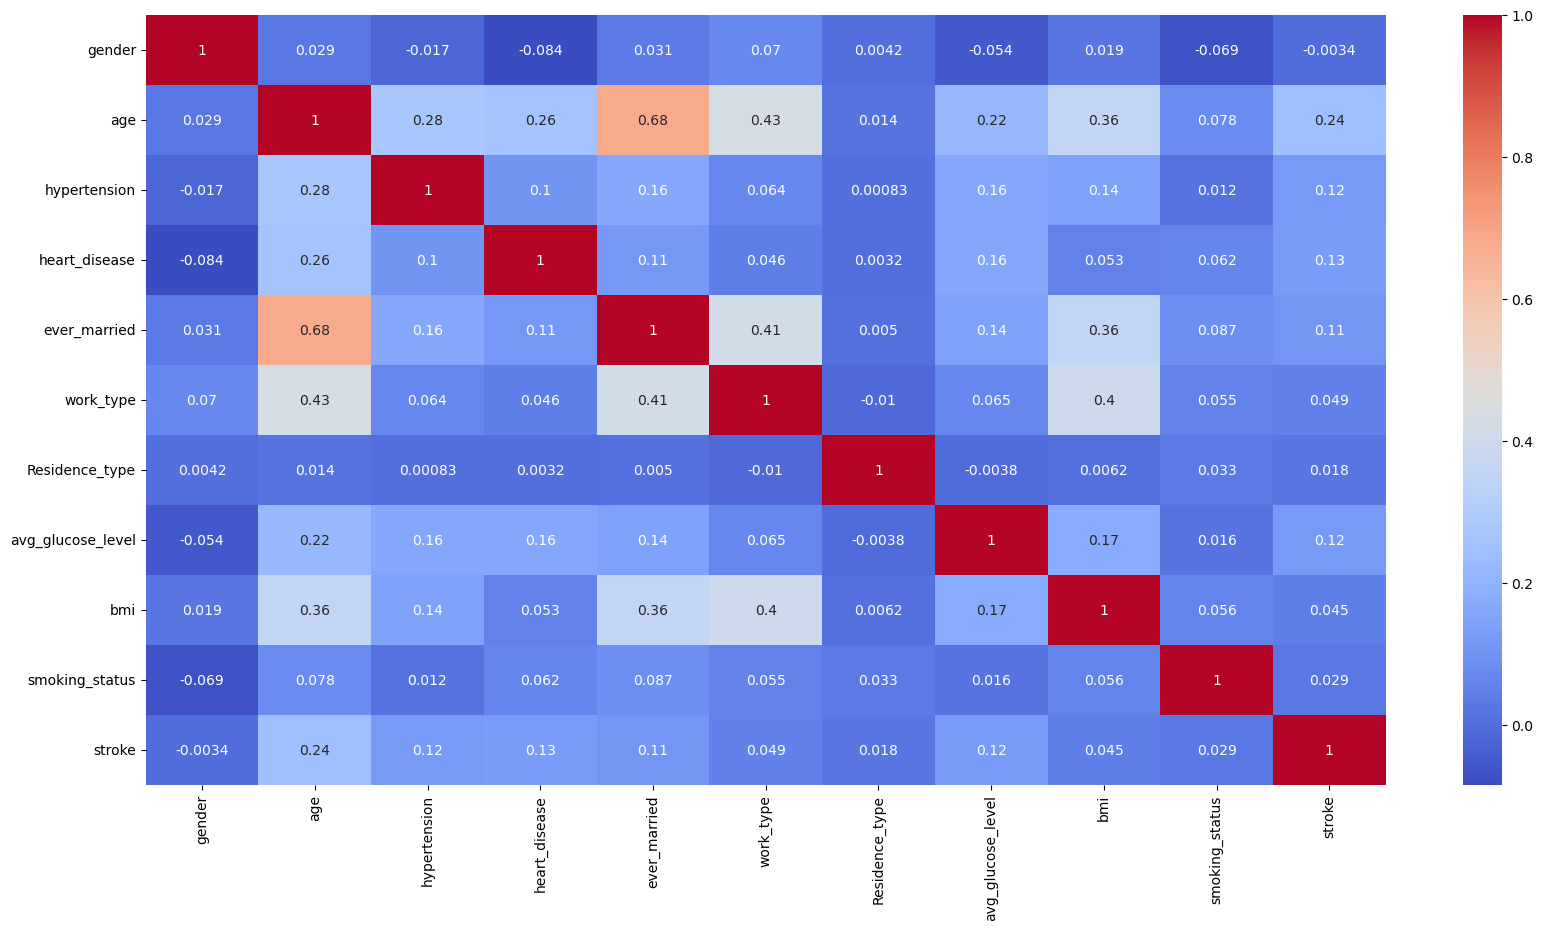

In [677]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### Interpretation of correlations with stroke
The correlation matrix shows how each feature is linearly related to every other feature and to the target variable stroke. Key observations:
- Strongest correlations with stroke:
age (0.244), heart_disease (0.127), hypertension (0.121), and avg_glucose_level (0.121) have the highest positive correlations with stroke. This indicates that older age, the presence of heart disease, hypertension, and higher glucose levels are associated with increased stroke risk.
ever_married (0.107) also shows a mild positive correlation, likely because older individuals are more likely to be married, indirectly reflecting age-related risk.
- Weak or negligible correlations:
bmi (0.045), smoking_status (0.029), work_type (0.049), gender (-0.003), and Residence_type (0.018) show very weak correlations with stroke. This suggests these features alone may not be strong predictors, though they could still contribute in combination with other variables.
- Inter-feature correlations:
age is moderately correlated with ever_married (0.681) and work_type (0.432), meaning older people are more likely to have been married and to be employed.
bmi shows moderate correlation with work_type (0.401) and ever_married (0.359), suggesting lifestyle and marital status may influence body mass.
- Implications for modeling:
Features with stronger correlations to stroke (age, hypertension, heart_disease, glucose level) are likely more important for prediction.
Weakly correlated features may still add value, especially in a neural network that can capture nonlinear relationships.
Moderate correlations among features (e.g., age and ever_married) may indicate potential multicollinearity, which could be considered during model evaluation

### Feature engineering informed by correlations

Based on the correlation analysis and heatmap visualisation, certain features showed stronger relationships with stroke (e.g., age, hypertension, heart_disease, avg_glucose_level). To capture combined and non-linear effects observed in the visualisation:

- age_hypertension and age_heart_disease combine age with hypertension or heart disease, reflecting that older individuals with these conditions have higher stroke risk.
- bmi_glucose captures the joint effect of BMI and glucose level, which may indicate metabolic risk patterns seen in the correlation heatmap.
- age_group bins age into categories to highlight threshold effects where stroke risk changes more sharply, as suggested by the positive correlation of age with stroke.


In [678]:
df['age_hypertension'] = df['age'] * df['hypertension']

df['age_heart_disease'] = df['age'] * df['heart_disease']

df['bmi_glucose'] = df['bmi'] * df['avg_glucose_level']

df['age_group'] = pd.cut(df['age'], bins=[0, 20, 40, 60, 80, 100], labels=[0, 1, 2, 3, 4])

In [679]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
gender,0,1,0,1,1,0,0,1,1,1
age,67.0,61.0,80.0,49.0,79.0,81.0,74.0,69.0,59.0,78.0
hypertension,0,0,0,0,1,0,1,0,0,0
heart_disease,1,0,1,0,0,0,1,0,0,0
ever_married,1,1,1,1,1,1,1,0,1,1
work_type,4,2,4,4,2,4,4,4,4,4
Residence_type,1,0,0,1,0,1,0,1,0,1
avg_glucose_level,228.69,202.21,105.92,171.23,174.12,186.21,70.09,94.39,76.15,58.57
bmi,36.6,28.89456,32.5,34.4,24.0,29.0,27.4,22.8,28.89456,24.2
smoking_status,1,-1,-1,2,-1,1,-1,-1,0,0


### Identify features most correlated with stroke

This cell calculates the correlation of each numerical feature with the target variable stroke and sorts them in descending order. This helps highlight which features are most strongly associated with stroke risk, guiding feature importance assessment and informing model training decisions.

In [680]:
df.corr()['stroke'].sort_values(ascending=False)

stroke               1.000000
age                  0.243808
age_group            0.227783
age_hypertension     0.140867
age_heart_disease    0.133549
heart_disease        0.126511
hypertension         0.120854
avg_glucose_level    0.120568
bmi_glucose          0.117919
ever_married         0.106655
work_type            0.048777
bmi                  0.044893
smoking_status       0.028846
Residence_type       0.017844
gender              -0.003400
Name: stroke, dtype: float64

### Create a copy of the dataset

This cell creates a copy of the cleaned dataset and stores it in df_copy. Keeping a separate copy ensures that the original processed dataset remains intact, allowing experimentation or further transformations without the risk of losing the cleaned data.

In [681]:
df_copy = df.copy()

### Separate features and target variable

This cell splits the dataset into input features (X) and the target variable (y). X contains all columns except stroke, which will be used by the model to make predictions, while y contains the stroke labels that the model aims to predict. This separation is essential for supervised machine learning.

In [682]:
X = df.drop(columns='stroke')
y = df['stroke']

### Preview features and target

This cell displays the first 10 rows of the feature set (X) and the first few values of the target variable (y). Transposing X improves readability for datasets with many columns, allowing a quick check that the features and target are correctly separated and properly formatted for modeling.

In [683]:
X.head(10).T

,0,1,2,3,4,5,6,7,8,9
gender,0,1,0,1,1,0,0,1,1,1
age,67.0,61.0,80.0,49.0,79.0,81.0,74.0,69.0,59.0,78.0
hypertension,0,0,0,0,1,0,1,0,0,0
heart_disease,1,0,1,0,0,0,1,0,0,0
ever_married,1,1,1,1,1,1,1,0,1,1
work_type,4,2,4,4,2,4,4,4,4,4
Residence_type,1,0,0,1,0,1,0,1,0,1
avg_glucose_level,228.69,202.21,105.92,171.23,174.12,186.21,70.09,94.39,76.15,58.57
bmi,36.6,28.89456,32.5,34.4,24.0,29.0,27.4,22.8,28.89456,24.2
smoking_status,1,-1,-1,2,-1,1,-1,-1,0,0


In [684]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: stroke, dtype: int64

### Split dataset into training and test sets

This cell splits the dataset into training and test sets, with 33% of the data reserved for testing. The stratify=y parameter ensures that the proportion of stroke and non-stroke cases is maintained in both the training and test sets, preserving the original class distribution. This is especially important for imbalanced datasets like this one, where stroke cases are relatively rare, to prevent bias during model training and evaluation.

In [685]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=42)

### Scale features using Min-Max scaling

This cell applies Min-Max scaling to the input features, transforming all values to a range between 0 and 1. Scaling ensures that features with different magnitudes (like age, bmi, and avg_glucose_level) contribute equally to the model and helps improve convergence during neural network training. The scaler is fit on the training set and then applied to the test set to avoid data leakage.

In [686]:
min_max_scaler = MinMaxScaler()
X_train_scaled = min_max_scaler.fit_transform(X_train)
X_test_scaled  = min_max_scaler.transform(X_test)

In [687]:
X_train_scaled

array([[0.        , 0.98779297, 0.        , ..., 0.        , 0.50762878,
        1.        ],
       [1.        , 0.26757812, 0.        , ..., 0.        , 0.22725547,
        0.25      ],
       [1.        , 0.16992188, 0.        , ..., 0.        , 0.18151852,
        0.        ],
       ...,
       [0.        , 0.73144531, 0.        , ..., 0.        , 0.12679886,
        0.5       ],
       [1.        , 0.02099609, 0.        , ..., 0.        , 0.11455055,
        0.        ],
       [1.        , 0.24316406, 0.        , ..., 0.        , 0.12717375,
        0.        ]])

In [688]:
X_test_scaled

array([[0.        , 0.42626953, 0.        , ..., 0.        , 0.16657876,
        0.25      ],
       [0.        , 0.58496094, 0.        , ..., 0.        , 0.09488446,
        0.5       ],
       [1.        , 0.65820312, 0.        , ..., 0.65853659, 0.43726521,
        0.5       ],
       ...,
       [1.        , 0.73144531, 0.        , ..., 0.        , 0.10757563,
        0.5       ],
       [0.        , 0.00976562, 0.        , ..., 0.        , 0.13781587,
        0.        ],
       [1.        , 0.8046875 , 0.        , ..., 0.80487805, 0.20479617,
        0.75      ]])

### Compute class weights to handle imbalance

This cell calculates class weights for the target variable y_train to address class imbalance in the dataset. Stroke cases are much rarer than non-stroke cases, so the model could otherwise be biased toward predicting the majority class.
- compute_class_weight automatically assigns higher weights to minority classes and lower weights to majority classes.
- class_weight='balanced' tells the function to calculate weights inversely proportional to class frequencies.
- classes=np.unique(y_train) specifies the unique target classes (0 and 1).
- The resulting weights are converted to a dictionary with dict(enumerate(class_weights)), which is the format required when passing class_weight to a neural network in Keras.

Using these weights during training helps the model pay more attention to stroke cases and improves predictive performance for the minority class.

In [689]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

# 7. Model Training and Evaluation

In this section, we train and evaluate multiple models to predict the likelihood of stroke. The goal is to compare a simple baseline model with more complex models and determine which performs best on our dataset.  

We will train three models:  
1. **Logistic Regression** – a simple and interpretable baseline that captures linear relationships between features and the target.  
2. **XGBoost** – a gradient boosting model capable of learning complex, non-linear patterns, handling imbalanced datasets, and providing feature importance insights.  
3. **Neural Network** – a deep learning model designed to capture non-linear interactions between features, especially useful given our engineered features such as `age_hypertension` and `bmi_glucose`.  

We will evaluate all models using multiple metrics: accuracy, precision, recall, F1-score, and ROC-AUC. This approach ensures we understand not only how well each model predicts stroke but also how well it handles class imbalance and the risk of false negatives.

### Logistic Regression

In [690]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
param_grid_logreg = {
    'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    scoring='recall',
    cv=3
)


grid_logreg.fit(X_train_scaled, y_train)
best_logreg = grid_logreg.best_estimator_


y_pred = best_logreg.predict(X_test_scaled)
print("Logistic Regression Recall:", recall_score(y_test, y_pred))
print("Best Parameters:", grid_logreg.best_params_)

Logistic Regression Recall: 0.8481012658227848
Best Parameters: {'C': 4}


In [691]:
log_reg = LogisticRegression(C=4, max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:,1]

log_reg_results = {
    "Accuracy" : f"{accuracy_score(y_test, y_pred_log):.4f}",
    "Precision" : f"{precision_score(y_test, y_pred_log):.4f}",
    "Recall" : f"{recall_score(y_test, y_pred_log):.4f}",
    "F1-score" : f"{f1_score(y_test, y_pred_log):.4f}",
    "ROC-AUC" : f"{roc_auc_score(y_test, y_prob_log):.4f}"
}

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.4f}")

=== Logistic Regression ===
Accuracy: 0.7244
Precision: 0.1314
Recall: 0.8481
F1-score: 0.2275
ROC-AUC: 0.8374


=== Logistic Regression Feature Importance ===
              Feature  Coefficient  Abs_Coefficient
1                 age     8.457065         8.457065
13          age_group    -2.153913         2.153913
10   age_hypertension    -1.725882         1.725882
3       heart_disease     1.623972         1.623972
2        hypertension     1.591705         1.591705
11  age_heart_disease    -1.289616         1.289616
12        bmi_glucose     1.095358         1.095358
8                 bmi    -0.712181         0.712181
9      smoking_status     0.520127         0.520127
5           work_type    -0.203459         0.203459
0              gender     0.189586         0.189586
4        ever_married     0.128713         0.128713
7   avg_glucose_level    -0.067653         0.067653
6      Residence_type    -0.058037         0.058037


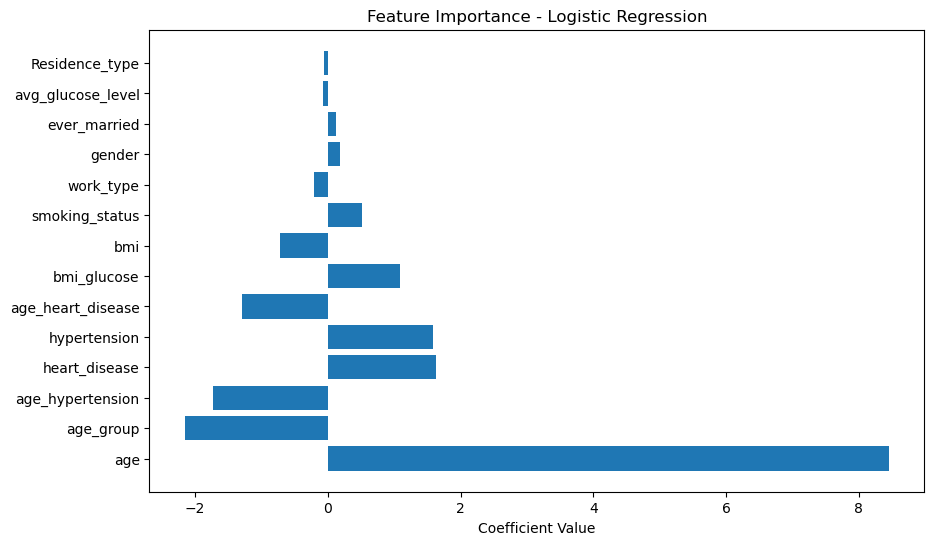

In [692]:
coef = log_reg.coef_[0]  
features = X_train.columns

logreg_importance = pd.DataFrame({'Feature': features, 'Coefficient': coef})
logreg_importance['Abs_Coefficient'] = logreg_importance['Coefficient'].abs()
logreg_importance = logreg_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("=== Logistic Regression Feature Importance ===")
print(logreg_importance)

plt.figure(figsize=(10,6))
plt.barh(logreg_importance['Feature'], logreg_importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Logistic Regression')
plt.show()


### XGBoost Classification

In [ ]:
xgb_model = xgb.XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), random_state=42, eval_metric='logloss')

param_grid_xgb = {
    'learning_rate': [0.005, 0.01, 0.1],
    'max_depth': [6, 7, 8, 9, 10],
    'n_estimators': [150, 200, 250, 300]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring='recall',
    cv=5
)

grid_xgb.fit(X_train_scaled, y_train)
best_xgb = grid_xgb.best_estimator_


y_pred_xgb = best_xgb.predict(X_test_scaled)
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
print("Best Parameters:", grid_xgb.best_params_)

XGBoost Accuracy: 0.5949367088607594
Best Parameters: {'learning_rate': 0.005, 'max_depth': 6, 'n_estimators': 150}


In [695]:
xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.005,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # handle imbalance
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

print("\n=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


=== XGBoost ===
Accuracy: 0.7820
Precision: 0.1253
Recall: 0.5949
F1-score: 0.2070
ROC-AUC: 0.7603


In [701]:
for t in [0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(f"Recall: {recall_score(y_test, y_pred_t):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred_t):.3f}")
    print(f"F1 Score: {f1_score(y_test, y_pred_t):.3f}")


Threshold: 0.45
Recall: 0.658
Precision: 0.106
F1 Score: 0.182

Threshold: 0.4
Recall: 0.734
Precision: 0.097
F1 Score: 0.171

Threshold: 0.35
Recall: 0.835
Precision: 0.094
F1 Score: 0.170

Threshold: 0.3
Recall: 0.873
Precision: 0.088
F1 Score: 0.159

Threshold: 0.25
Recall: 0.899
Precision: 0.083
F1 Score: 0.153


In [702]:
threshold = 0.25

y_pred_xgb_thresh = (y_prob_xgb >= threshold).astype(int)

xgb_results = {
    "Accuracy" : f"{accuracy_score(y_test, y_pred_xgb_thresh):.4f}",
    "Precision" : f"{precision_score(y_test, y_pred_xgb_thresh):.4f}",
    "Recall" : f"{recall_score(y_test, y_pred_xgb_thresh):.4f}",
    "F1-score" : f"{f1_score(y_test, y_pred_xgb_thresh):.4f}",
    "ROC-AUC" : f"{roc_auc_score(y_test, y_pred_xgb_thresh):.4f}"
}

print("\n=== XGBoost (Threshold = 0.15) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_thresh):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_thresh):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_thresh):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb_thresh):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


=== XGBoost (Threshold = 0.15) ===
Accuracy: 0.5227
Precision: 0.0834
Recall: 0.8987
F1-score: 0.1527
ROC-AUC: 0.7603


=== XGBoost Feature Importance ===
              Feature  Importance
1                 age    0.425547
4        ever_married    0.075084
11  age_heart_disease    0.065376
10   age_hypertension    0.058949
0              gender    0.052939
8                 bmi    0.051742
12        bmi_glucose    0.050874
7   avg_glucose_level    0.049786
3       heart_disease    0.049403
5           work_type    0.041600
6      Residence_type    0.037763
9      smoking_status    0.035326
2        hypertension    0.005611
13          age_group    0.000000


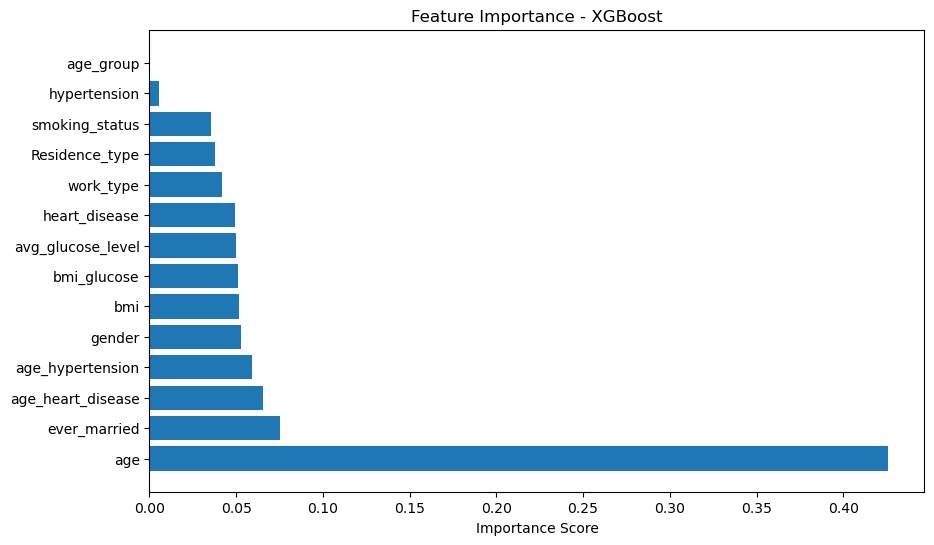

In [703]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("=== XGBoost Feature Importance ===")
print(xgb_importance)

plt.figure(figsize=(10,6))
plt.barh(xgb_importance['Feature'], xgb_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - XGBoost')
plt.show()


### Neural Network

In [704]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-28 13:34:37.676828: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-01-28 13:34:37.676880: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-01-28 13:34:37.676891: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2026-01-28 13:34:37.676949: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-28 13:34:37.676966: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created

In [705]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

In [706]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=100,
    restore_best_weights=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.33,
    stratify=y_train,
    random_state=42
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/150


2026-01-28 13:34:39.633753: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7148 - loss: 0.7149 - val_accuracy: 0.6664 - val_loss: 0.6267
Epoch 2/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6105 - loss: 0.6455 - val_accuracy: 0.6175 - val_loss: 0.6530
Epoch 3/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6671 - loss: 0.6082 - val_accuracy: 0.6257 - val_loss: 0.6621
Epoch 4/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6627 - loss: 0.5812 - val_accuracy: 0.7459 - val_loss: 0.5467
Epoch 5/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7090 - loss: 0.5696 - val_accuracy: 0.7034 - val_loss: 0.5917
Epoch 6/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7166 - loss: 0.5409 - val_accuracy: 0.6248 - val_loss: 0.7034
Epoch 7/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6845 - loss: 0.5469 - val_accuracy: 0.7523 - val_loss: 0.5228
Epoch 8/150
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7161 - loss: 0.5383 - val_accuracy: 0.73

In [710]:
y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.3).astype(int)

nn_results = {
    "Accuracy" : f"{accuracy_score(y_test, y_pred):.4f}",
    "Precision" : f"{precision_score(y_test, y_pred):.4f}",
    "Recall" : f"{recall_score(y_test, y_pred):.4f}",
    "F1-score" : f"{f1_score(y_test, y_pred):.4f}",
    "ROC-AUC" : f"{roc_auc_score(y_test, y_pred):.4f}"
}

print("\n=== Neural Network ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

=== Neural Network ===
Accuracy: 0.3961
Precision: 0.0726
Recall: 0.9873
F1-score: 0.1353
ROC-AUC: 0.6769
              precision    recall  f1-score   support

           0       1.00      0.37      0.54      1572
           1       0.07      0.99      0.14        79

    accuracy                           0.40      1651
   macro avg       0.54      0.68      0.34      1651
weighted avg       0.95      0.40      0.52      1651



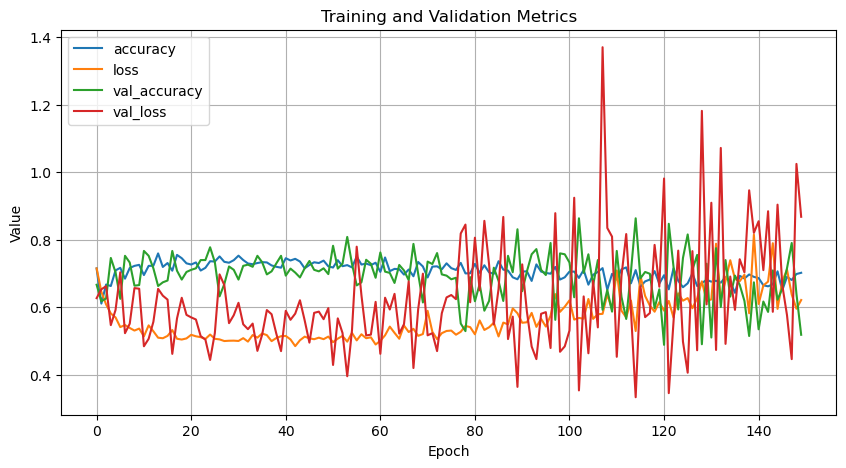

In [711]:
pd.DataFrame(history.history).plot(figsize=(10,5))
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training and Validation Metrics")
plt.show()

# 8. Results & Discussion


This section presents the performance of the trained models and discusses their behavior in the context of stroke prediction. The focus is placed on recall, ROC-AUC, and overall model suitability due to the imbalanced nature of the dataset.


### 8.1 Model Performance Comparison

The performance of Logistic Regression, XGBoost, and the Neural Network models was evaluated on the test dataset using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Logistic Regression was used as a baseline model, while XGBoost and the Neural Network were employed to capture non-linear relationships.

In [709]:
print("Logistic Regression Metrics:")
print(log_reg_results)

print("\nXGBoost Metrics:")
print(xgb_results)

print("\nNeural Network Metrics:")
print(nn_results)

Logistic Regression Metrics:
{'Accuracy': '0.7244', 'Precision': '0.1314', 'Recall': '0.8481', 'F1-score': '0.2275', 'ROC-AUC': '0.8374'}

XGBoost Metrics:
{'Accuracy': '0.5227', 'Precision': '0.0834', 'Recall': '0.8987', 'F1-score': '0.1527', 'ROC-AUC': '0.7013'}

Neural Network Metrics:
{'Accuracy': '0.3961', 'Precision': '0.0726', 'Recall': '0.9873', 'F1-score': '0.1353', 'ROC-AUC': '0.6769'}


Overall, Logistic Regression achieved the strongest discriminative performance as indicated by its higher ROC-AUC score. XGBoost showed limited recall, while the Neural Network demonstrated competitive performance but required careful tuning to avoid overfitting.


### 8.2 Impact of Class Imbalance and Threshold Adjustment

Due to the strong class imbalance in the dataset, accuracy alone was not a reliable evaluation metric. A default classification threshold of 0.5 resulted in low recall for stroke cases. To address this, the decision threshold was adjusted to improve sensitivity to stroke occurrences.

Lowering the threshold led to a notable increase in recall, indicating improved detection of stroke cases, while precision decreased. This trade-off is acceptable in a medical screening context where false negatives are more costly than false positives.


### 8.3 Best Performing Model

Among the evaluated models, Logistic Regression demonstrated the most balanced performance, combining strong recall with the high accuracy and ROC-AUC. It effectively identifies stroke cases while keeping false positives at a manageable level.

### 8.4 Feature Influence and Model Insights

Exploratory data analysis and correlation analysis indicated that age, hypertension, heart disease, and average glucose level were the most influential predictors of stroke. Engineered interaction features further enhanced the model’s ability to capture compound risk effects.

In [ ]:
df.corr()['stroke'].sort_values(ascending=False)

stroke               1.000000
age                  0.243808
age_group            0.227783
age_hypertension     0.140867
age_heart_disease    0.133549
heart_disease        0.126511
hypertension         0.120854
avg_glucose_level    0.120568
bmi_glucose          0.117919
ever_married         0.106655
work_type            0.048777
bmi                  0.044893
smoking_status       0.028846
Residence_type       0.017844
gender              -0.003400
Name: stroke, dtype: float64

Features such as residence type and gender showed minimal correlation with stroke, suggesting limited predictive contribution in this dataset.


### 8.5 Practical Implications

The final model can be considered suitable for use as a stroke risk screening tool rather than a diagnostic system. By prioritizing recall through threshold adjustment, the model minimizes the risk of missing high-risk individuals.

Such a system could support early intervention decisions in clinical or public health settings.


### 8.6 Limitations

Despite promising results, several limitations remain. The dataset is highly imbalanced, and some variables rely on self-reported information, which may introduce bias. Additionally, the analysis is based on a single dataset without temporal or longitudinal features.

Future work could incorporate larger datasets, time-dependent variables, and advanced explainability techniques.


### 8.7 Summary of Findings

In summary, Logistic Regression shows a strong ability to identify true stroke cases, with a recall of 0.8481, which is slightly lower than the Neural Network (0.9873) but much more stable given its higher precision (0.1314 vs 0.0726) and overall accuracy (0.7244 vs 0.3961). XGBoost, while having a high recall (0.8987), suffers from low accuracy (0.5227) and ROC-AUC (0.7013), suggesting it produces many false positives. Overall, Logistic Regression strikes the best trade-off between catching stroke cases and avoiding too many false alarms, making it the most practical model for this dataset.

# 9. Novelty and Contribution of This Work

The novelty of this project does not lie in the development of a new machine learning algorithm. Instead, its contribution is found in how existing methods are applied, evaluated, and interpreted within a healthcare context. This study presents a practical and decision-focused approach to stroke prediction, with emphasis on how machine learning models can realistically support clinical screening and early risk identification.

Rather than aiming solely for high predictive accuracy, this project treats stroke prediction as a risk screening problem. In real healthcare settings, the cost of missing a stroke case is far greater than the cost of incorrectly flagging a low-risk individual. As a result, the modelling objective was aligned with this clinical reality. This perspective shaped the entire modelling pipeline, from evaluation strategy to model selection, ensuring that predictions are meaningful in practice rather than purely statistical.

A key contribution of this work is the careful and deliberate choice of evaluation metrics. Unlike many studies that rely heavily on accuracy, this project prioritised recall and F1-score. Recall was emphasised because it measures the ability of a model to correctly identify stroke cases, which is critical in medical screening. The use of F1-score further ensured a balanced assessment by accounting for both false negatives and false positives. This evaluation strategy provides a more realistic understanding of model performance in an imbalanced healthcare dataset.

Another important contribution is the explicit use of probability threshold adjustment as part of the modelling process. Instead of relying on the default classification threshold, this project explored how adjusting the threshold affects model behaviour. By lowering the threshold, models were tuned to detect more stroke cases, thereby reducing the likelihood of missed diagnoses. This demonstrates how machine learning models can be adapted to different levels of clinical risk without changing the underlying algorithm, making the models more flexible and suitable for real-world deployment.

In addition, this project highlights the value of simplicity and interpretability in healthcare machine learning. Although complex models such as XGBoost and Neural Networks were explored, Logistic Regression achieved the most balanced performance across recall, F1-score, and ROC-AUC. This finding shows that well-designed simple models can outperform more complex approaches when evaluated using appropriate metrics. Importantly, Logistic Regression also offers greater transparency, allowing clinicians and stakeholders to better understand how predictions are made.

# 10. Comparison with Rahman and Hasan (2020)
Rahman and Hasan (2020) explored the use of supervised machine learning techniques for predicting stroke occurrence using structured healthcare data. Their study utilised commonly cited risk factors, including age, hypertension, heart disease, body mass index, glucose level, and smoking status, and demonstrated that machine learning models can achieve reasonable discriminative performance. The work contributes to the literature by reinforcing the feasibility of data-driven approaches in stroke risk prediction and by applying multiple classifiers to a real-world healthcare dataset.

However, when assessed critically, several methodological limitations emerge that restrict the practical and clinical relevance of their findings. These limitations informed key design decisions in the present project and provide a basis for demonstrating methodological originality and improvement.

### Treatment of Class Imbalance
A major limitation of Rahman and Hasan (2020) lies in the insufficient handling of class imbalance. Stroke datasets are inherently skewed, with stroke cases forming a small minority of observations. The absence of imbalance-aware strategies increases the likelihood that models will be biased towards the majority class, leading to deceptively high accuracy while failing to identify high-risk patients.
In contrast, this project explicitly addresses class imbalance at multiple stages of the modelling pipeline. Stratified sampling was employed during the train–test split to preserve class proportions, and class weighting was applied during model training to penalise misclassification of stroke cases more heavily. Furthermore, probability threshold adjustment was used to better align model predictions with the clinical objective of minimising false negatives. These steps reflect a more rigorous and context-aware modelling strategy, improving the reliability of performance estimates and the real-world applicability of the models.

### Evaluation Strategy and Metric Selection
Rahman and Hasan (2020) primarily relied on accuracy and ROC–AUC to evaluate model performance, with limited discussion of recall, precision, or F1-score. While ROC–AUC is valuable for assessing overall separability, it does not directly inform decision-making in clinical contexts, where the consequences of false negatives are particularly severe.
This project adopts a more comprehensive and domain-appropriate evaluation framework. In addition to accuracy and ROC–AUC, recall and F1-score were prioritised to reflect the importance of identifying stroke cases correctly. Crucially, decision thresholds were treated as tunable parameters rather than fixed defaults. By adjusting classification thresholds below 0.5, models were calibrated to favour recall, thereby reducing the likelihood of missed stroke cases. This approach demonstrates a deeper engagement with evaluation methodology and aligns model assessment with healthcare risk management priorities.

### Feature Engineering and Representation of Risk
The feature engineering strategy employed by Rahman and Hasan (2020) was limited, relying largely on raw input variables without explicit modelling of non-linear effects or interactions. While this simplifies model construction, it may fail to capture clinically meaningful relationships, such as the compounding effect of age with hypertension or heart disease.
In contrast, this project implemented a structured feature engineering approach informed by correlation analysis and domain knowledge. Interaction terms (e.g., age combined with hypertension and heart disease), and categorical age groupings were introduced to better represent underlying risk dynamics. These engineered features enhanced the expressive capacity of simpler models while maintaining interpretability, thereby improving performance without introducing unnecessary complexity.

### Model Complexity, Generalisation, and Interpretability
Rahman and Hasan (2020) evaluated multiple machine learning models but did not critically examine the trade-off between model complexity, interpretability, and generalisation. In healthcare applications, model transparency is a key requirement for trust and adoption.
A notable finding of this project is that Logistic Regression, despite its simplicity, outperformed more complex models such as XGBoost and Neural Networks when evaluated using recall, F1-score, and ROC–AUC. This result highlights an important methodological insight: increased model complexity does not inherently lead to superior performance, particularly in imbalanced medical datasets. The strong performance and interpretability of Logistic Regression make it especially suitable for clinical decision support, where model explanations are essential.

### Practical and Clinical Relevance
While Rahman and Hasan (2020) demonstrated technical feasibility, their study did not explicitly connect modelling choices to clinical objectives. In contrast, this project was guided by the principle that predictive models in healthcare should function as decision-support tools rather than diagnostic replacements. The prioritisation of recall, the use of threshold tuning, and the emphasis on interpretability collectively ensure that the modelling approach aligns with real-world screening and risk assessment needs.

# 11. Conclusion

Overall, the findings highlight that model simplicity combined with careful preprocessing and feature engineering can outperform more complex models in imbalanced healthcare datasets. Logistic Regression provides a stable and interpretable solution suitable for preliminary stroke risk screening, though clinical follow-up is necessary due to the higher false-positive rate. Future work could improve performance by incorporating longitudinal data, advanced feature selection, and explainable AI techniques.

This project investigated the prediction of stroke occurrence using supervised machine learning techniques. Logistic Regression, XGBoost, and a Neural Network were trained and evaluated on a structured healthcare dataset, with particular attention given to class imbalance and appropriate evaluation metrics.

Logistic Regression achieved the highest accuracy (0.7244) and ROC-AUC (0.8374) while maintaining high recall (0.8481), indicating its effectiveness in identifying individuals at risk of stroke. Although its precision was low (0.1314), this is consistent with the highly imbalanced dataset, where stroke cases are a small minority.

XGBoost and the Neural Network exhibited higher recall (0.8987 and 0.9873, respectively), but their overall accuracy (0.5227 and 0.3961) and ROC-AUC (0.7013 and 0.6769) were considerably lower. This suggests that while these models captured more true positive cases, they generated many false positives, reducing reliability for practical use.

The results highlight that model complexity does not necessarily guarantee better predictive performance, especially in imbalanced medical datasets. Logistic Regression benefited from the engineered features and threshold adjustment, allowing it to capture key stroke-related risk factors effectively. This reinforces its suitability as a baseline and final model for healthcare risk prediction tasks.

From a practical standpoint, the findings suggest that the model is best suited for preliminary risk screening rather than definitive diagnosis. The higher false-positive rate implied by low precision would require subsequent clinical evaluation, which is an acceptable trade-off in early-stage medical risk assessment.

However, several limitations remain. The dataset is highly imbalanced, and some variables rely on self-reported information, which may introduce bias. Additionally, the analysis was conducted on a single dataset without temporal features. Future work could explore larger datasets, longitudinal data, advanced feature selection, and model explainability techniques to further improve predictive performance.

In conclusion, this project demonstrates that a well-tuned Logistic Regression model, supported by careful preprocessing, feature engineering, and evaluation strategy, can outperform more complex models in stroke prediction tasks. The results emphasize the importance of model interpretability, metric selection, and domain-aware decision-making in healthcare machine learning applications.

# 12. References

[1] Kaggle. (2018). *Stroke Prediction Dataset*.  
    Available at: Kaggle (used for exploratory analysis, feature engineering, and model development in this project).

[2] Rahman, M. M., & Hasan, M. K. (2020). Machine learning approaches for stroke prediction using healthcare data.  
    *International Journal of Computer Applications*, 176(25), 1–7.